In [3]:
# Enable automatic reloading of imported modules
%load_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Import ONLY the engine and the circuit from your friend's file
from l_vqe_functions import simulate_one_lvqe, _apply_lvqe_circuit

=== SETUP: 5-Node Max-Cut ===


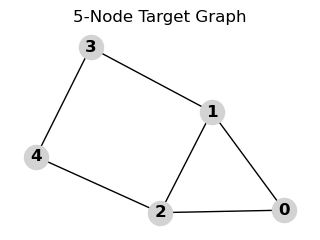

Hamiltonian initialized for 5 qubits over 6 edges.


In [4]:
print("=== SETUP: 5-Node Max-Cut ===")

# 1. Map the 5-node diagram (0: Left, 1: Top-mid, 2: Bot-mid, 3: Top-right, 4: Bot-right)
G_5 = nx.Graph()
G_5.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4)])
n_qubits = len(G_5.nodes)  # Max-Cut requires exactly 1 qubit per node (k=2)

# Draw it to verify the geometry
plt.figure(figsize=(3, 2))
nx.draw(G_5, with_labels=True, node_color='lightgray', font_weight='bold')
plt.title("5-Node Target Graph")
plt.show()

# 2. Define the EXACT Max-Cut Hamiltonian
def create_exact_maxcut_hamiltonian(graph):
    """Minimizing this Hamiltonian directly outputs the negative number of cuts."""
    coeffs = []
    observables = []
    for u, v in graph.edges:
        coeffs.append(-0.5)
        observables.append(qml.Identity(u)) 
        
        coeffs.append(0.5)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
        
    return qml.Hamiltonian(coeffs, observables)

H_maxcut = create_exact_maxcut_hamiltonian(G_5)
print(f"Hamiltonian initialized for {n_qubits} qubits over {len(G_5.edges)} edges.")

=== RUNNING L-VQE ENGINE ===
  Layer 0  (5 params) ... cost = -4.997500
  Layer 1  (21 params) ... cost = -5.000000
  Layer 2  (37 params) ... cost = -5.000000

Final Cost (Number of Cuts): 5.00 out of 6


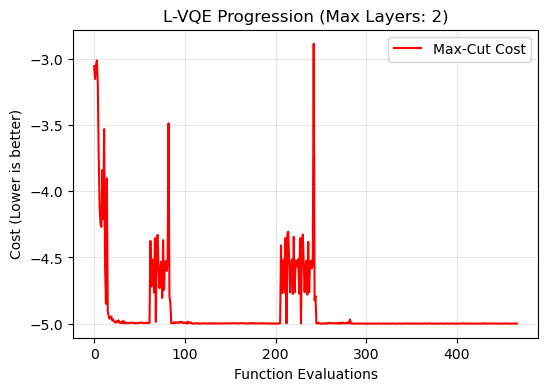


=== DECODING QUANTUM STATE ===
Top 3 Most Probable Node Groupings:
----------------------------------------
Bitstring: |01001⟩ | Probability:  99.8%
  -> Set 0: [0, 2, 3]
  -> Set 1: [1, 4]

Bitstring: |11001⟩ | Probability:   0.1%
  -> Set 0: [2, 3]
  -> Set 1: [0, 1, 4]

Bitstring: |00101⟩ | Probability:   0.0%
  -> Set 0: [0, 1, 3]
  -> Set 1: [2, 4]



In [8]:
print("=== RUNNING L-VQE ENGINE ===")

# 1. Run the simulation using your friend's engine
max_layers = 2
shots = 4000
rng = np.random.default_rng(42)

results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_maxcut,
    max_layers=max_layers,
    shots=shots,
    max_iter_per_layer=200,
    rng=rng
)

trained_params = results["final_params"]
cost_history = results["cost_history"]
print(f"\nFinal Cost (Number of Cuts): {-results['final_cost']:.2f} out of {len(G_5.edges)}")

# 2. Plot the Optimization Curve
plt.figure(figsize=(6, 4))
plt.plot(cost_history, label="Max-Cut Cost", color='red')
plt.title(f"L-VQE Progression (Max Layers: {max_layers})")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost (Lower is better)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3. Decode the Winning State
print("\n=== DECODING QUANTUM STATE ===")
dev_read = qml.device("default.qubit", wires=n_qubits, shots=shots)

@qml.qnode(dev_read)
def read_circuit(params):
    # Use your friend's private circuit function to rebuild the final state
    _apply_lvqe_circuit(params, n_qubits, max_layers)
    return qml.counts()

counts = read_circuit(trained_params)
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

print("Top 3 Most Probable Node Groupings:")
print("-" * 40)
for bitstring, count in sorted_counts[:3]:
    prob = (count / shots) * 100
    print(f"Bitstring: |{bitstring}⟩ | Probability: {prob:5.1f}%")
    
    # Optional: Map the 0s and 1s back to physical nodes
    group_0 = [node for node, bit in enumerate(bitstring) if bit == '0']
    group_1 = [node for node, bit in enumerate(bitstring) if bit == '1']
    print(f"  -> Set 0: {group_0}")
    print(f"  -> Set 1: {group_1}\n")

=== SCALING VERIFICATION: 8-Node Platonic Cube ===


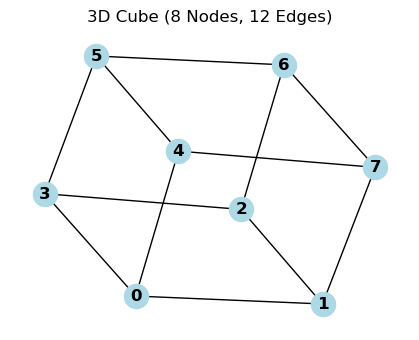

  Layer 0  (8 params) ... cost = -12.000000
  Layer 1  (36 params) ... cost = -12.000000
  Layer 2  (64 params) ... cost = -12.000000

Final Cost (Number of Cuts): 11.99 out of 12 possible


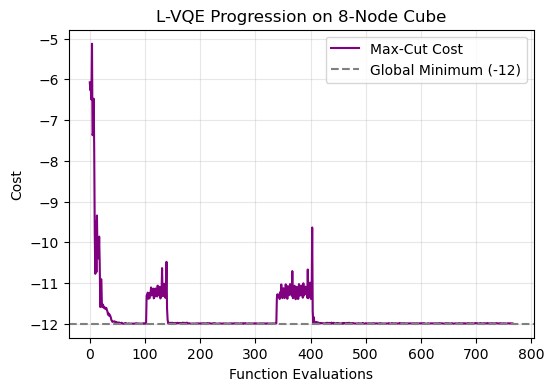


=== DECODING QUANTUM STATE ===
Top 3 Most Probable Node Groupings:
----------------------------------------
Bitstring: |01011010⟩ | Probability:  99.6%
Bitstring: |01010010⟩ | Probability:   0.1%
Bitstring: |01011011⟩ | Probability:   0.1%


In [9]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Import the engine and circuit from your friend's file
from l_vqe_functions import simulate_one_lvqe, _apply_lvqe_circuit

print("=== SCALING VERIFICATION: 8-Node Platonic Cube ===")

# 1. Build the 3D Cube Graph (Nodes 0 to 7)
G_cube = nx.cubical_graph()
n_qubits = len(G_cube.nodes)
n_edges = len(G_cube.edges)

# Visualize the graph
plt.figure(figsize=(4, 3))
nx.draw(G_cube, with_labels=True, node_color='lightblue', font_weight='bold')
plt.title(f"3D Cube ({n_qubits} Nodes, {n_edges} Edges)")
plt.show()

# 2. Define the EXACT Max-Cut Hamiltonian
def create_exact_maxcut_hamiltonian(graph):
    coeffs = []
    observables = []
    for u, v in graph.edges:
        coeffs.append(-0.5)
        observables.append(qml.Identity(u)) 
        
        coeffs.append(0.5)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
        
    return qml.Hamiltonian(coeffs, observables)

H_cube = create_exact_maxcut_hamiltonian(G_cube)

# 3. Run L-VQE (We allow up to Layer 2 for this larger space)
max_layers = 2
shots = 2000
rng = np.random.default_rng(42)

results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_cube,
    max_layers=max_layers,
    shots=shots,
    max_iter_per_layer=250, # Slightly higher budget for 8 qubits
    rng=rng
)

trained_params = results["final_params"]
cost_history = results["cost_history"]
print(f"\nFinal Cost (Number of Cuts): {-results['final_cost']:.2f} out of {n_edges} possible")

# 4. Plot the Optimization Curve
plt.figure(figsize=(6, 4))
plt.plot(cost_history, label="Max-Cut Cost", color='purple')
plt.axhline(-12, color="gray", linestyle="--", label="Global Minimum (-12)")
plt.title(f"L-VQE Progression on 8-Node Cube")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5. Decode the Winning State
print("\n=== DECODING QUANTUM STATE ===")
dev_read = qml.device("default.qubit", wires=n_qubits, shots=shots)

@qml.qnode(dev_read)
def read_circuit(params):
    _apply_lvqe_circuit(params, n_qubits, max_layers)
    return qml.counts()

counts = read_circuit(trained_params)
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

print("Top 3 Most Probable Node Groupings:")
print("-" * 40)
for bitstring, count in sorted_counts[:3]:
    prob = (count / shots) * 100
    print(f"Bitstring: |{bitstring}⟩ | Probability: {prob:5.1f}%")

=== THE FRUSTRATION TEST: 12-Node Random Regular Graph ===
Running classical brute-force solver...
-> True Global Maximum: 16 cuts (out of 18 total edges)
-> Number of degenerate perfect solutions: 6


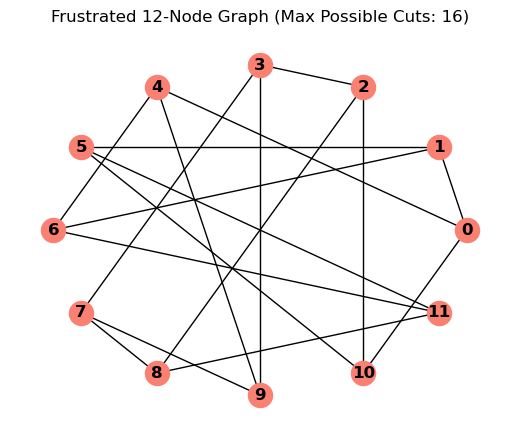


Running L-VQE Quantum Optimization...
  Layer 0  (12 params) ... cost = -15.916500
  Layer 1  (56 params) ... cost = -15.916000
  Layer 2  (100 params) ... cost = -15.987500

=== FINAL BENCHMARK ===
True Classical Max-Cut : 16
Quantum L-VQE Max-Cut  : 15.98
Approximation Ratio (ρ): 0.9987


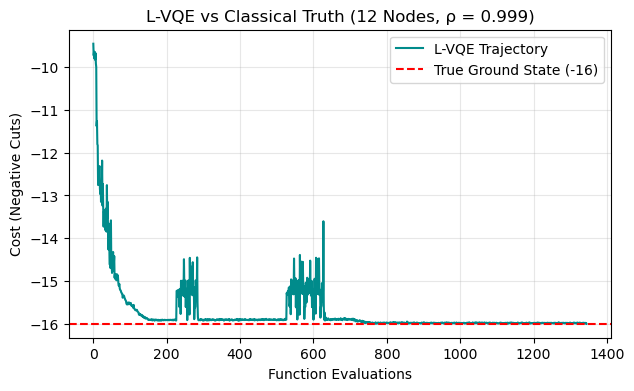


=== DECODING TOP QUANTUM STATES ===
Top 3 Quantum Guesses vs Classical Truth:
|010110001011⟩ :  98.6% probability  [✓ PERFECT]
|010110001010⟩ :   0.5% probability  [✗ SUB-OPTIMAL]
|010110000011⟩ :   0.2% probability  [✗ SUB-OPTIMAL]


In [11]:
import itertools
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Import your friend's engine
from l_vqe_functions import simulate_one_lvqe, _apply_lvqe_circuit

print("=== THE FRUSTRATION TEST: 12-Node Random Regular Graph ===")

# ---------------------------------------------------------
# 1. CLASSICAL EXACT SOLVER (The Infallible Benchmark)
# ---------------------------------------------------------
def find_exact_maxcut(graph):
    """Brute-forces all 2^N combinations to find the true Maximum Cut."""
    n = len(graph.nodes)
    max_cut_val = 0
    best_bitstrings = []
    
    # Generate all possible binary strings of length n
    for bits in itertools.product([0, 1], repeat=n):
        cut_val = 0
        for u, v in graph.edges:
            if bits[u] != bits[v]:
                cut_val += 1
                
        if cut_val > max_cut_val:
            max_cut_val = cut_val
            best_bitstrings = ["".join(map(str, bits))]
        elif cut_val == max_cut_val:
            best_bitstrings.append("".join(map(str, bits)))
            
    return max_cut_val, best_bitstrings

# ---------------------------------------------------------
# 2. GRAPH & HAMILTONIAN SETUP
# ---------------------------------------------------------
n_qubits = 12
# A 3-regular graph guarantees high frustration
G_tough = nx.random_regular_graph(d=3, n=n_qubits, seed=101)
n_edges = len(G_tough.edges)

# Calculate the True Classical Benchmark
print("Running classical brute-force solver...")
true_max_cut, true_bitstrings = find_exact_maxcut(G_tough)
print(f"-> True Global Maximum: {true_max_cut} cuts (out of {n_edges} total edges)")
print(f"-> Number of degenerate perfect solutions: {len(true_bitstrings)}")

# Draw the Frustrated Graph
plt.figure(figsize=(5, 4))
nx.draw_circular(G_tough, with_labels=True, node_color='salmon', font_weight='bold')
plt.title(f"Frustrated 12-Node Graph (Max Possible Cuts: {true_max_cut})")
plt.show()

# Exact Max-Cut Hamiltonian
def create_exact_maxcut_hamiltonian(graph):
    coeffs = []
    observables = []
    for u, v in graph.edges:
        coeffs.append(-0.5)
        observables.append(qml.Identity(u)) 
        coeffs.append(0.5)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
    return qml.Hamiltonian(coeffs, observables)

H_tough = create_exact_maxcut_hamiltonian(G_tough)

# ---------------------------------------------------------
# 3. RUNNING THE QUANTUM ENGINE
# ---------------------------------------------------------
max_layers = 2
shots = 2000
# We give COBYLA more iterations because 12 qubits + 2 layers = 96 parameters
max_iter = 300 
rng = np.random.default_rng(42)

print("\nRunning L-VQE Quantum Optimization...")
results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_tough,
    max_layers=max_layers,
    shots=shots,
    max_iter_per_layer=max_iter,
    rng=rng
)

quantum_cuts_found = -results['final_cost']
cost_history = results["cost_history"]

# ---------------------------------------------------------
# 4. BENCHMARK COMPARISON & PLOTTING
# ---------------------------------------------------------
# Calculate the Approximation Ratio (rho)
rho = quantum_cuts_found / true_max_cut

print("\n=== FINAL BENCHMARK ===")
print(f"True Classical Max-Cut : {true_max_cut}")
print(f"Quantum L-VQE Max-Cut  : {quantum_cuts_found:.2f}")
print(f"Approximation Ratio (ρ): {rho:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(cost_history, label="L-VQE Trajectory", color='darkcyan')
# The classical benchmark is the floor
plt.axhline(-true_max_cut, color="red", linestyle="--", label=f"True Ground State (-{true_max_cut})")
plt.title(f"L-VQE vs Classical Truth (12 Nodes, ρ = {rho:.3f})")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost (Negative Cuts)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 5. VERIFYING THE QUANTUM STATES
# ---------------------------------------------------------
print("\n=== DECODING TOP QUANTUM STATES ===")
dev_read = qml.device("default.qubit", wires=n_qubits, shots=shots)

@qml.qnode(dev_read)
def read_circuit(params):
    _apply_lvqe_circuit(params, n_qubits, max_layers)
    return qml.counts()

counts = read_circuit(results["final_params"])
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

print("Top 3 Quantum Guesses vs Classical Truth:")
for bitstring, count in sorted_counts[:3]:
    prob = (count / shots) * 100
    is_perfect = "✓ PERFECT" if bitstring in true_bitstrings else "✗ SUB-OPTIMAL"
    print(f"|{bitstring}⟩ : {prob:5.1f}% probability  [{is_perfect}]")

=== THE FRUSTRATION TEST: 12-Node Random Regular Graph ===
Running classical brute-force solver...
-> True Global Maximum: 16 cuts (out of 18 total edges)
-> Number of degenerate perfect solutions: 6


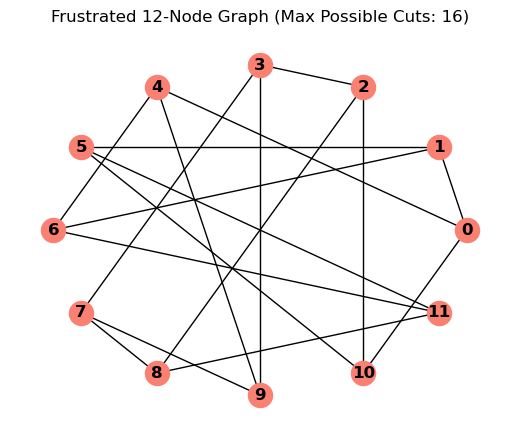


Running L-VQE Quantum Optimization...
  Layer 0  (12 params) ... cost = -14.939000
  Layer 1  (56 params) ... cost = -15.500500
  Layer 2  (100 params) ... cost = -15.948000

=== FINAL BENCHMARK ===
True Classical Max-Cut : 16
Quantum L-VQE Max-Cut  : 15.93
Approximation Ratio (ρ): 0.9958


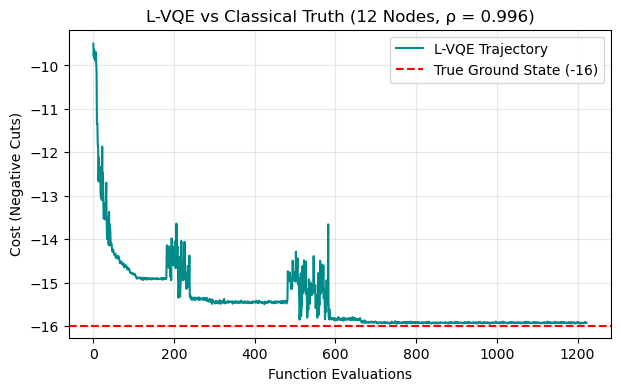


=== DECODING TOP QUANTUM STATES ===
Top 3 Quantum Guesses vs Classical Truth:
|010110001011⟩ :  93.9% probability  [✓ PERFECT]
|010110001111⟩ :   3.5% probability  [✗ SUB-OPTIMAL]
|010110001010⟩ :   1.7% probability  [✗ SUB-OPTIMAL]


In [12]:
import itertools
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Import your friend's engine
from l_vqe_functions import simulate_one_lvqe, _apply_lvqe_circuit

print("=== THE FRUSTRATION TEST: 12-Node Random Regular Graph ===")

# ---------------------------------------------------------
# 1. CLASSICAL EXACT SOLVER (The Infallible Benchmark)
# ---------------------------------------------------------
def find_exact_maxcut(graph):
    """Brute-forces all 2^N combinations to find the true Maximum Cut."""
    n = len(graph.nodes)
    max_cut_val = 0
    best_bitstrings = []
    
    # Generate all possible binary strings of length n
    for bits in itertools.product([0, 1], repeat=n):
        cut_val = 0
        for u, v in graph.edges:
            if bits[u] != bits[v]:
                cut_val += 1
                
        if cut_val > max_cut_val:
            max_cut_val = cut_val
            best_bitstrings = ["".join(map(str, bits))]
        elif cut_val == max_cut_val:
            best_bitstrings.append("".join(map(str, bits)))
            
    return max_cut_val, best_bitstrings

# ---------------------------------------------------------
# 2. GRAPH & HAMILTONIAN SETUP
# ---------------------------------------------------------
n_qubits = 12
# A 3-regular graph guarantees high frustration
G_tough = nx.random_regular_graph(d=3, n=n_qubits, seed=101)
n_edges = len(G_tough.edges)

# Calculate the True Classical Benchmark
print("Running classical brute-force solver...")
true_max_cut, true_bitstrings = find_exact_maxcut(G_tough)
print(f"-> True Global Maximum: {true_max_cut} cuts (out of {n_edges} total edges)")
print(f"-> Number of degenerate perfect solutions: {len(true_bitstrings)}")

# Draw the Frustrated Graph
plt.figure(figsize=(5, 4))
nx.draw_circular(G_tough, with_labels=True, node_color='salmon', font_weight='bold')
plt.title(f"Frustrated 12-Node Graph (Max Possible Cuts: {true_max_cut})")
plt.show()

# Exact Max-Cut Hamiltonian
def create_exact_maxcut_hamiltonian(graph):
    coeffs = []
    observables = []
    for u, v in graph.edges:
        coeffs.append(-0.5)
        observables.append(qml.Identity(u)) 
        coeffs.append(0.5)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
    return qml.Hamiltonian(coeffs, observables)

H_tough = create_exact_maxcut_hamiltonian(G_tough)

# ---------------------------------------------------------
# 3. RUNNING THE QUANTUM ENGINE
# ---------------------------------------------------------
max_layers = 2
shots = 2000
# We give COBYLA more iterations because 12 qubits + 2 layers = 96 parameters
max_iter = 300 
rng = np.random.default_rng(42)

print("\nRunning L-VQE Quantum Optimization...")
results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_tough,
    max_layers=max_layers,
    shots=shots,
    max_iter_per_layer=max_iter,
    rng=rng
)

quantum_cuts_found = -results['final_cost']
cost_history = results["cost_history"]

# ---------------------------------------------------------
# 4. BENCHMARK COMPARISON & PLOTTING
# ---------------------------------------------------------
# Calculate the Approximation Ratio (rho)
rho = quantum_cuts_found / true_max_cut

print("\n=== FINAL BENCHMARK ===")
print(f"True Classical Max-Cut : {true_max_cut}")
print(f"Quantum L-VQE Max-Cut  : {quantum_cuts_found:.2f}")
print(f"Approximation Ratio (ρ): {rho:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(cost_history, label="L-VQE Trajectory", color='darkcyan')
# The classical benchmark is the floor
plt.axhline(-true_max_cut, color="red", linestyle="--", label=f"True Ground State (-{true_max_cut})")
plt.title(f"L-VQE vs Classical Truth (12 Nodes, ρ = {rho:.3f})")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost (Negative Cuts)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 5. VERIFYING THE QUANTUM STATES
# ---------------------------------------------------------
print("\n=== DECODING TOP QUANTUM STATES ===")
dev_read = qml.device("default.qubit", wires=n_qubits, shots=shots)

@qml.qnode(dev_read)
def read_circuit(params):
    _apply_lvqe_circuit(params, n_qubits, max_layers)
    return qml.counts()

counts = read_circuit(results["final_params"])
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

print("Top 3 Quantum Guesses vs Classical Truth:")
for bitstring, count in sorted_counts[:3]:
    prob = (count / shots) * 100
    is_perfect = "✓ PERFECT" if bitstring in true_bitstrings else "✗ SUB-OPTIMAL"
    print(f"|{bitstring}⟩ : {prob:5.1f}% probability  [{is_perfect}]")

=== THE FRUSTRATION TEST: 12-Node Random Regular Graph ===
Running classical brute-force solver...
-> True Global Maximum: 16 cuts (out of 18 total edges)
-> Number of degenerate perfect solutions: 6


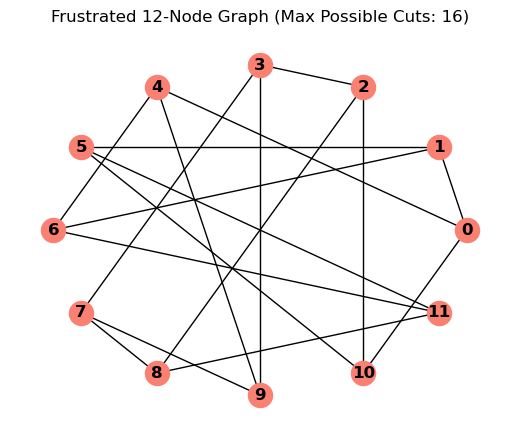


Running L-VQE Quantum Optimization...
  Layer 0  (12 params) ... cost = -13.482000
  Layer 1  (56 params) ... cost = -13.878500
  Layer 2  (100 params) ... cost = -13.904000

=== FINAL BENCHMARK ===
True Classical Max-Cut : 16
Quantum L-VQE Max-Cut  : 13.87
Approximation Ratio (ρ): 0.8672


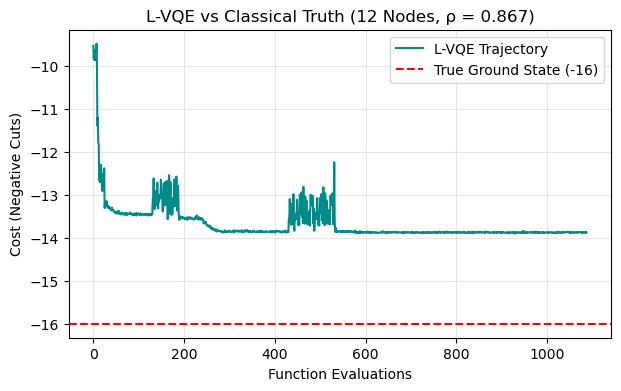


=== DECODING TOP QUANTUM STATES ===
Top 3 Quantum Guesses vs Classical Truth:
|010100101110⟩ :  89.3% probability  [✗ SUB-OPTIMAL]
|010100001110⟩ :   7.0% probability  [✗ SUB-OPTIMAL]
|010101101110⟩ :   0.9% probability  [✗ SUB-OPTIMAL]


In [13]:
import itertools
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Import your friend's engine
from l_vqe_functions import simulate_one_lvqe, _apply_lvqe_circuit

print("=== THE FRUSTRATION TEST: 12-Node Random Regular Graph ===")

# ---------------------------------------------------------
# 1. CLASSICAL EXACT SOLVER (The Infallible Benchmark)
# ---------------------------------------------------------
def find_exact_maxcut(graph):
    """Brute-forces all 2^N combinations to find the true Maximum Cut."""
    n = len(graph.nodes)
    max_cut_val = 0
    best_bitstrings = []
    
    # Generate all possible binary strings of length n
    for bits in itertools.product([0, 1], repeat=n):
        cut_val = 0
        for u, v in graph.edges:
            if bits[u] != bits[v]:
                cut_val += 1
                
        if cut_val > max_cut_val:
            max_cut_val = cut_val
            best_bitstrings = ["".join(map(str, bits))]
        elif cut_val == max_cut_val:
            best_bitstrings.append("".join(map(str, bits)))
            
    return max_cut_val, best_bitstrings

# ---------------------------------------------------------
# 2. GRAPH & HAMILTONIAN SETUP
# ---------------------------------------------------------
n_qubits = 12
# A 3-regular graph guarantees high frustration
G_tough = nx.random_regular_graph(d=3, n=n_qubits, seed=101)
n_edges = len(G_tough.edges)

# Calculate the True Classical Benchmark
print("Running classical brute-force solver...")
true_max_cut, true_bitstrings = find_exact_maxcut(G_tough)
print(f"-> True Global Maximum: {true_max_cut} cuts (out of {n_edges} total edges)")
print(f"-> Number of degenerate perfect solutions: {len(true_bitstrings)}")

# Draw the Frustrated Graph
plt.figure(figsize=(5, 4))
nx.draw_circular(G_tough, with_labels=True, node_color='salmon', font_weight='bold')
plt.title(f"Frustrated 12-Node Graph (Max Possible Cuts: {true_max_cut})")
plt.show()

# Exact Max-Cut Hamiltonian
def create_exact_maxcut_hamiltonian(graph):
    coeffs = []
    observables = []
    for u, v in graph.edges:
        coeffs.append(-0.5)
        observables.append(qml.Identity(u)) 
        coeffs.append(0.5)
        observables.append(qml.PauliZ(u) @ qml.PauliZ(v))
    return qml.Hamiltonian(coeffs, observables)

H_tough = create_exact_maxcut_hamiltonian(G_tough)

# ---------------------------------------------------------
# 3. RUNNING THE QUANTUM ENGINE
# ---------------------------------------------------------
max_layers = 2
shots = 2000
# We give COBYLA more iterations because 12 qubits + 2 layers = 96 parameters
max_iter = 300 
rng = np.random.default_rng(42)

print("\nRunning L-VQE Quantum Optimization...")
results = simulate_one_lvqe(
    n_q=n_qubits,
    H=H_tough,
    max_layers=max_layers,
    shots=shots,
    max_iter_per_layer=max_iter,
    rng=rng
)

quantum_cuts_found = -results['final_cost']
cost_history = results["cost_history"]

# ---------------------------------------------------------
# 4. BENCHMARK COMPARISON & PLOTTING
# ---------------------------------------------------------
# Calculate the Approximation Ratio (rho)
rho = quantum_cuts_found / true_max_cut

print("\n=== FINAL BENCHMARK ===")
print(f"True Classical Max-Cut : {true_max_cut}")
print(f"Quantum L-VQE Max-Cut  : {quantum_cuts_found:.2f}")
print(f"Approximation Ratio (ρ): {rho:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(cost_history, label="L-VQE Trajectory", color='darkcyan')
# The classical benchmark is the floor
plt.axhline(-true_max_cut, color="red", linestyle="--", label=f"True Ground State (-{true_max_cut})")
plt.title(f"L-VQE vs Classical Truth (12 Nodes, ρ = {rho:.3f})")
plt.xlabel("Function Evaluations")
plt.ylabel("Cost (Negative Cuts)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 5. VERIFYING THE QUANTUM STATES
# ---------------------------------------------------------
print("\n=== DECODING TOP QUANTUM STATES ===")
dev_read = qml.device("default.qubit", wires=n_qubits, shots=shots)

@qml.qnode(dev_read)
def read_circuit(params):
    _apply_lvqe_circuit(params, n_qubits, max_layers)
    return qml.counts()

counts = read_circuit(results["final_params"])
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

print("Top 3 Quantum Guesses vs Classical Truth:")
for bitstring, count in sorted_counts[:3]:
    prob = (count / shots) * 100
    is_perfect = "✓ PERFECT" if bitstring in true_bitstrings else "✗ SUB-OPTIMAL"
    print(f"|{bitstring}⟩ : {prob:5.1f}% probability  [{is_perfect}]")